# Линейная регрессия и градиентный спуск с нуля

Проект посвящен реализации оптимизации и линейной регрессии без использования готового `LinearRegression` для обучения весов.

Реализованы MSE, обычный и стохастический градиентный спуск, затухающий шаг, L2 регуляризация и Huber Loss.

## Базовые функции потерь и градиенты

In [53]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

In [54]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        return np.mean((X@w-y)**2)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        return (2*X.T@ (X@w-y))/X.shape[0]

In [55]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


In [56]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    w =w_init.copy()
    w_list=[w.copy()]

    for i in range(n_iterations):
        w -=lr*loss.calc_grad(X,y,w)
        w_list.append(w.copy())

    return w_list

In [59]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

In [61]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    w =w_init.copy()
    w_list = [w.copy()]

    for i in range(n_iterations):
        sample = np.random.choice(X.shape[0],size=batch_size,replace=False)
        w -= lr * loss.calc_grad(X[sample],y[sample], w)
        w_list.append(w.copy())

    return w_list

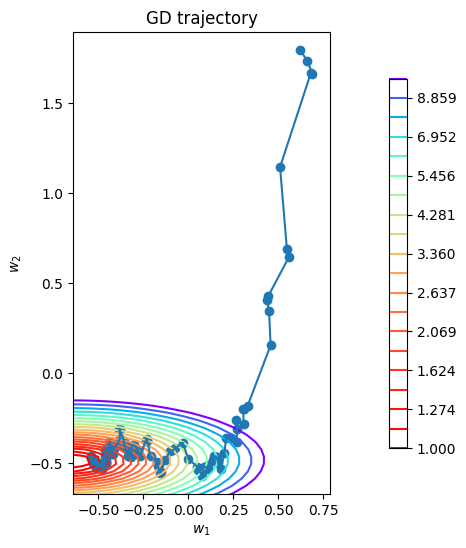

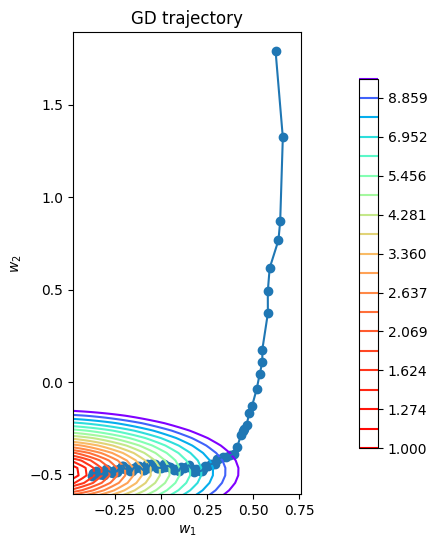

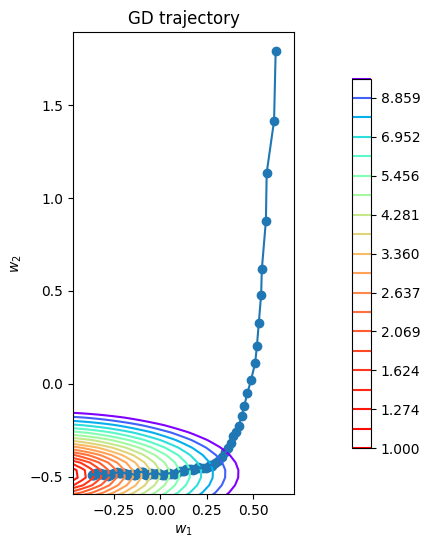

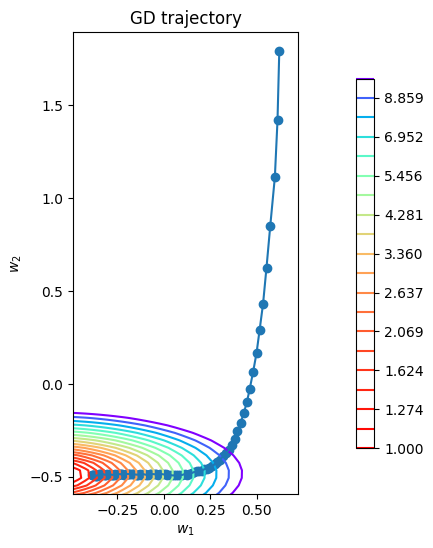

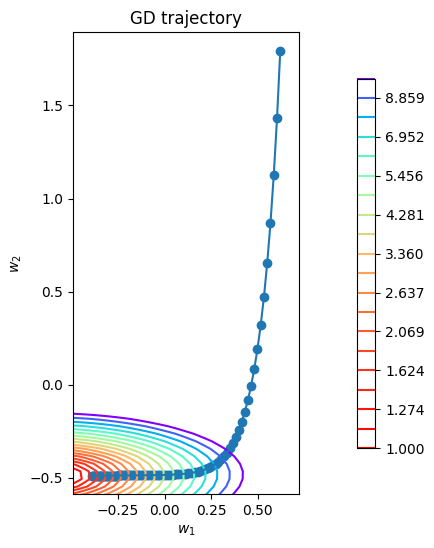

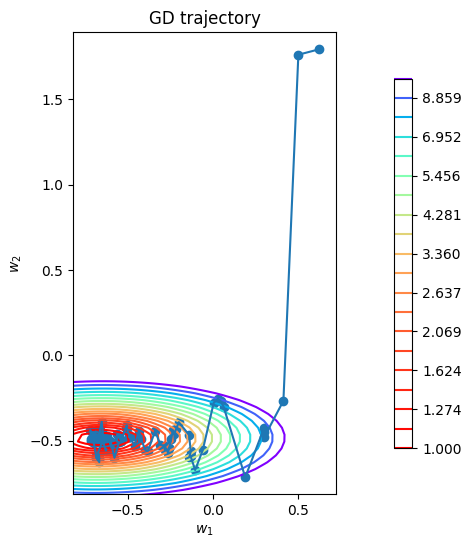

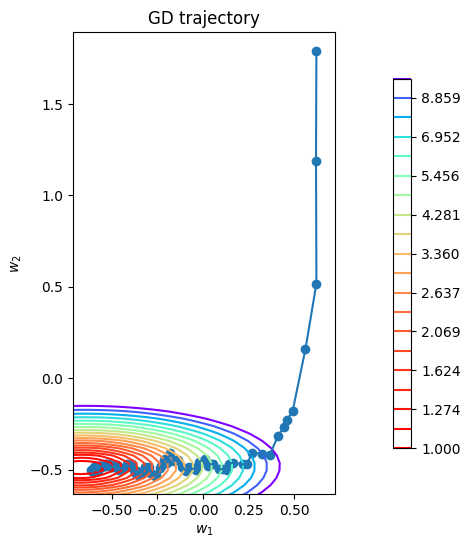

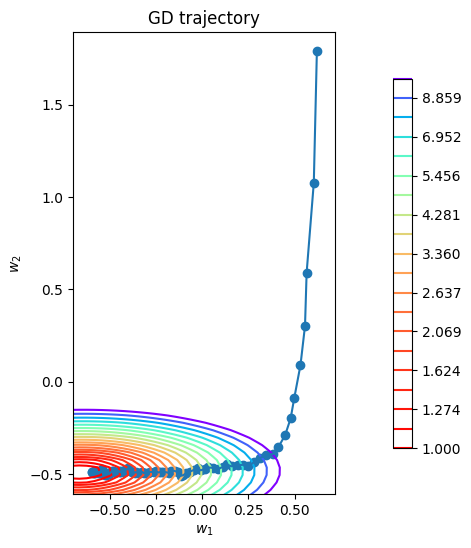

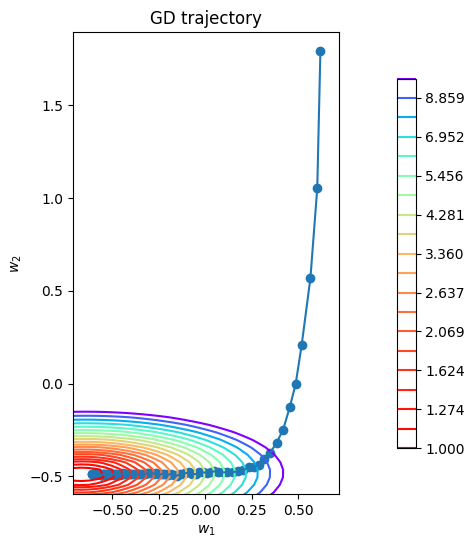

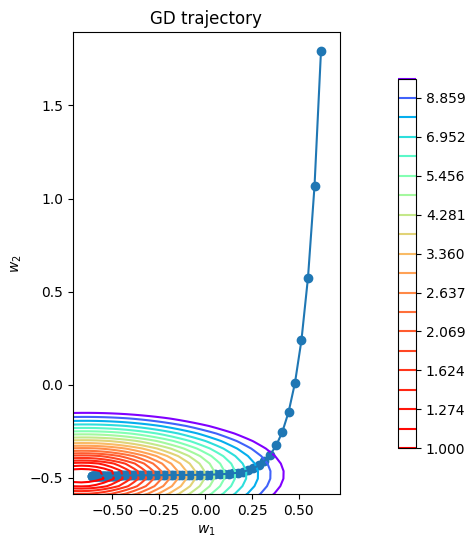

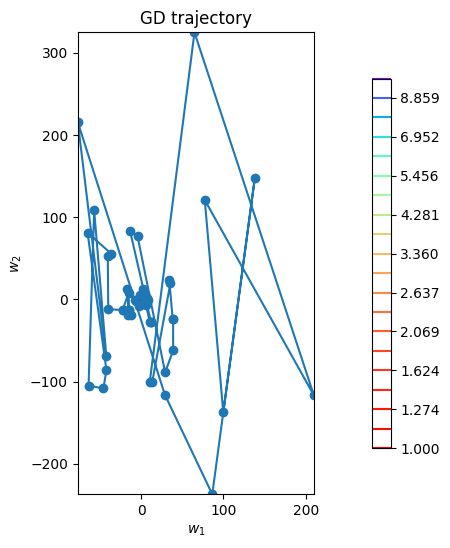

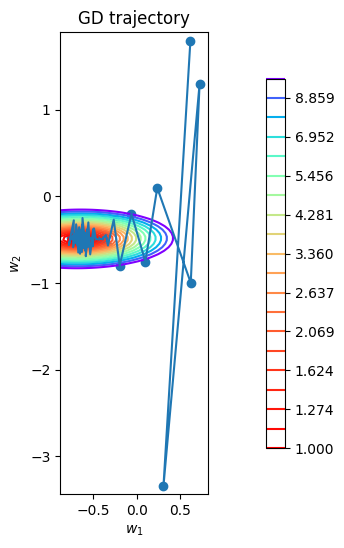

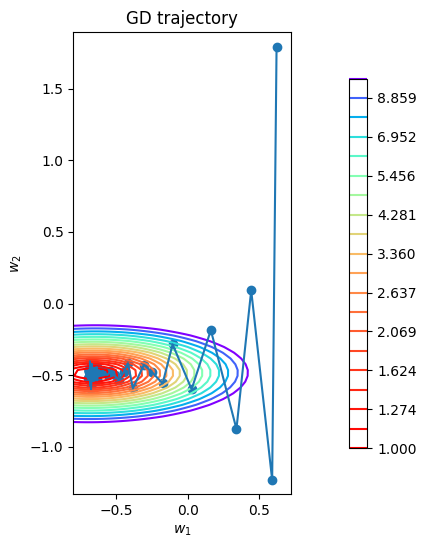

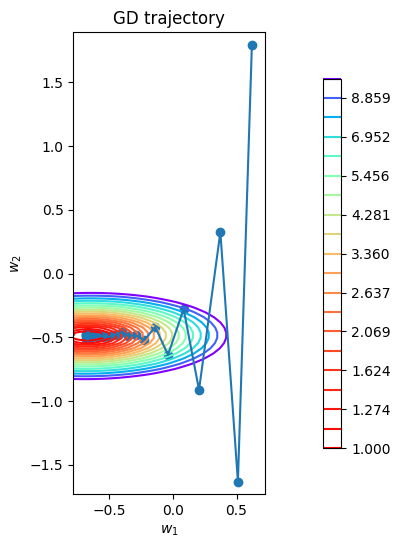

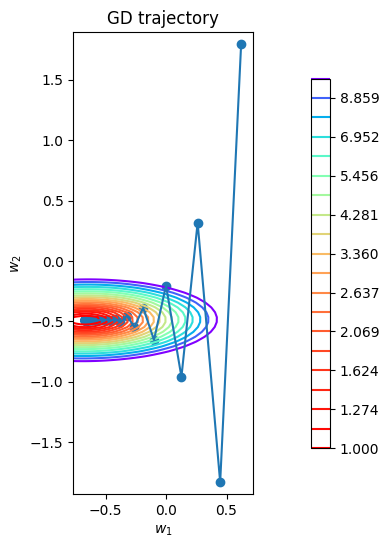

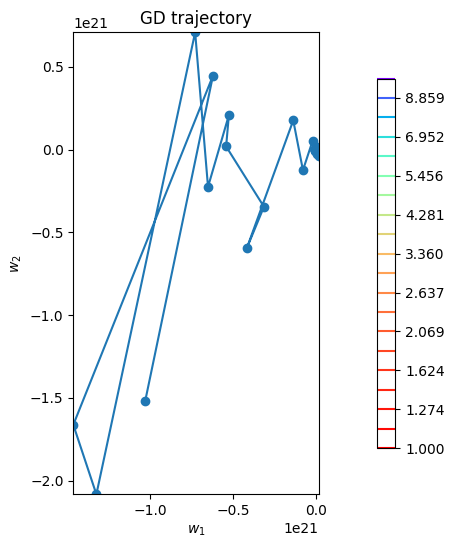

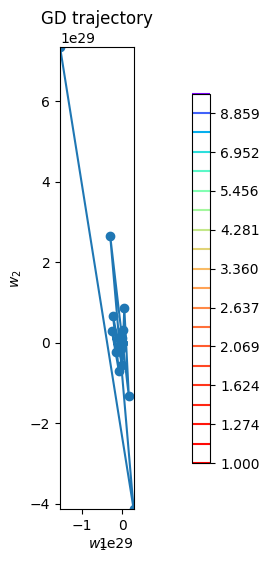

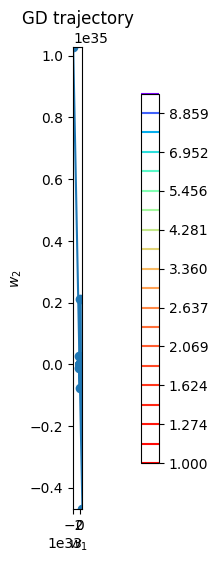

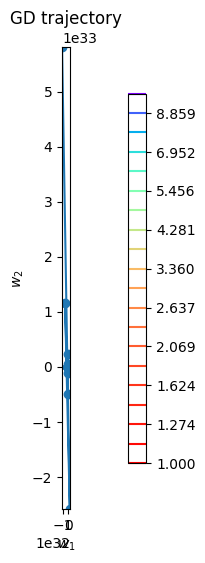

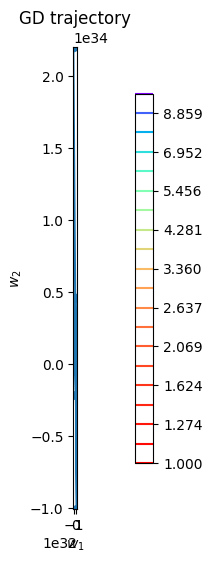

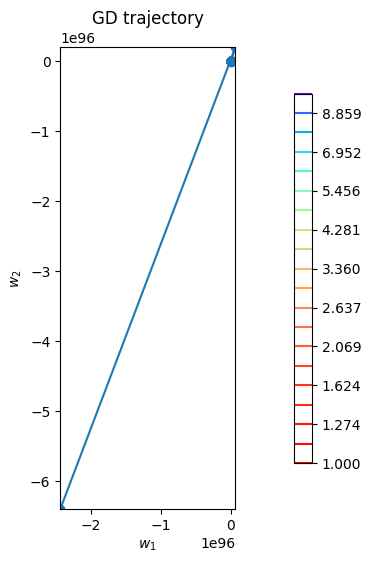

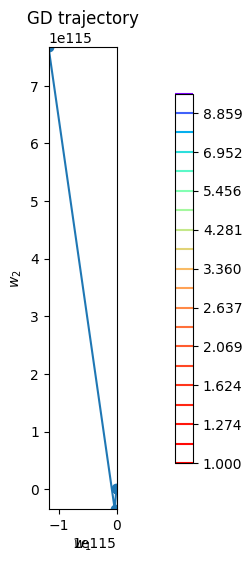

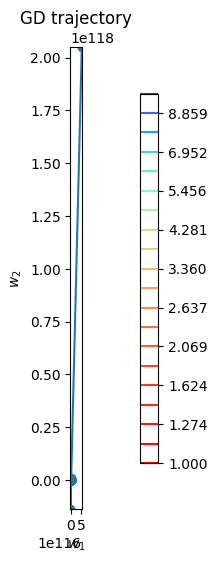

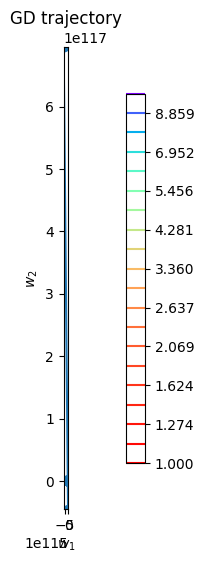

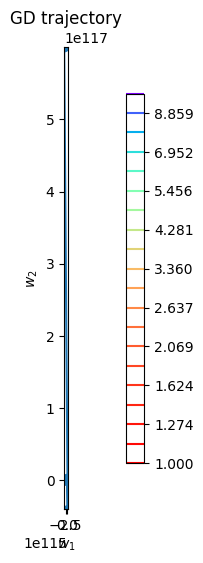

In [62]:
for lr in [0.001,0.002,0.01,0.02, 0.1]:
    for batch_size in [1,10,50, 150,300]:
        w_list =stochastic_gradient_descent(w_init,X,y, loss,lr=lr,batch_size=batch_size,n_iterations=100)
        plot_gd(w_list,X,y,loss)

In [63]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    w =w_init.copy()
    w_list=[w.copy()]

    for i in range(n_iterations):
        step_size=lr*np.power(1/(1+i),p)
        sample=np.random.choice(X.shape[0],size=batch_size,replace=False)
        w -=step_size*loss.calc_grad(X[sample],y[sample],w)
        w_list.append(w.copy())

    return w_list

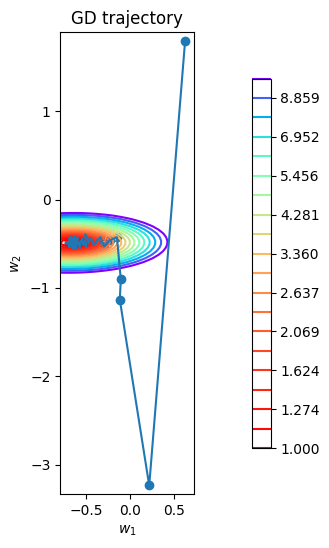

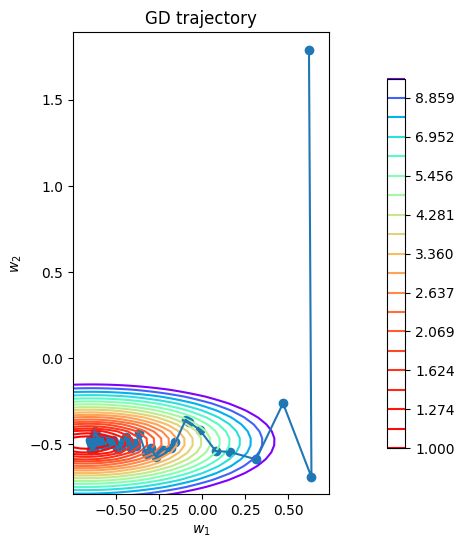

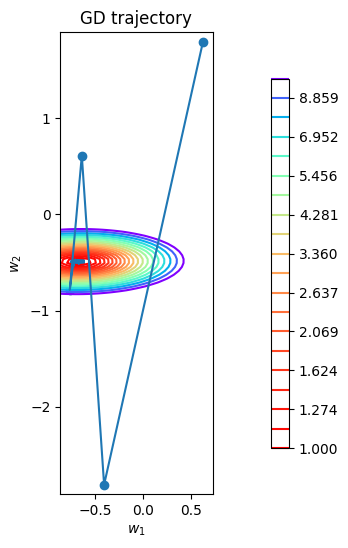

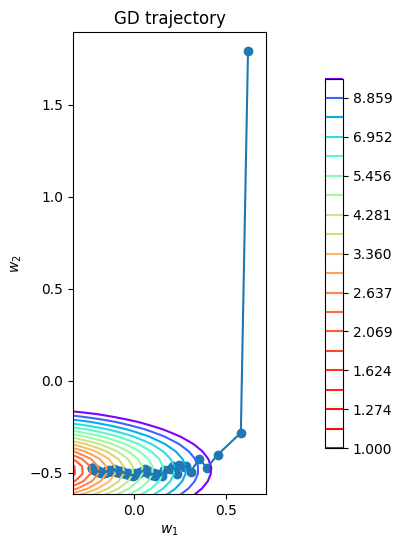

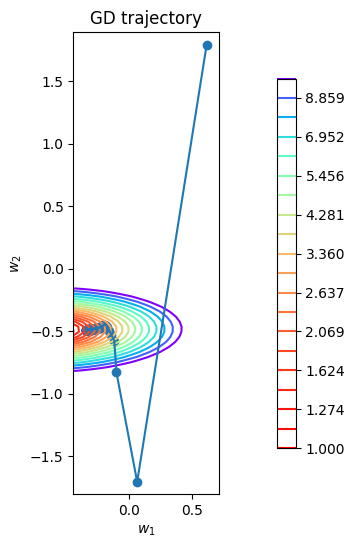

In [64]:
for p in [0.1,0.3,0.5,0.8,1]:
    w_list = stochastic_gradient_descent(w_init,X,y,loss,lr=0.01,batch_size=10,p=p, n_iterations=100)
    plot_gd(w_list,X,y,loss)

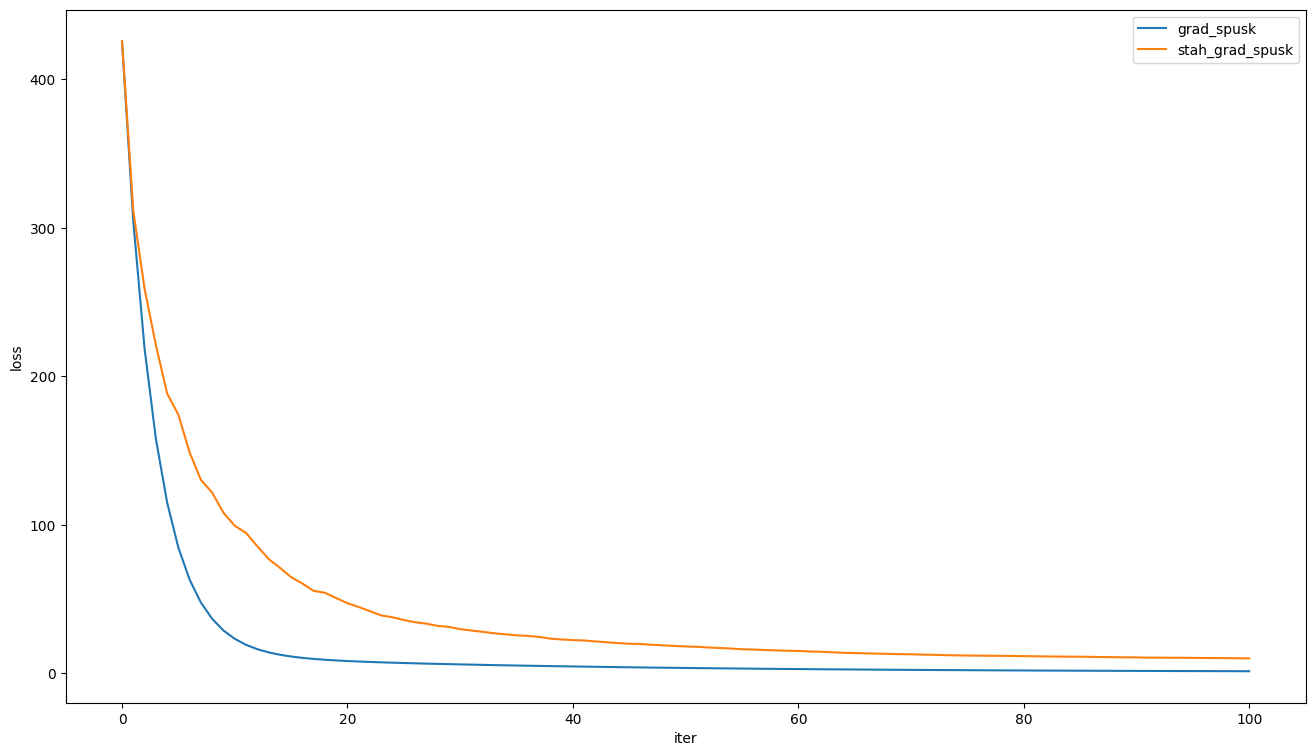

In [65]:
trace_grad_spusk=gradient_descent(w_init, X, y, loss, lr=0.001,n_iterations=100)
trace_stah_grad_spusk=stochastic_gradient_descent(w_init, X, y, loss, lr=0.001, batch_size=10,p=0.5, n_iterations=100)
loss_of_grad_spusk= [loss.calc_loss(X,y,w) for w in trace_grad_spusk]
loss_of_stah_grad_spusk=[loss.calc_loss(X,y,w) for w in trace_stah_grad_spusk]

plt.figure(figsize=(16,9))
plt.plot(loss_of_grad_spusk,label="grad_spusk")
plt.plot(loss_of_stah_grad_spusk,label="stah_grad_spusk")
plt.xlabel("iter")
plt.ylabel("loss")
plt.legend()

## Линейная регрессия с собственным оптимизатором

Класс использует тот же интерфейс `fit/predict`, но веса подбираются собственной реализацией градиентного спуска.

In [66]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        w_init = np.random.uniform(-2,2,X.shape[1])
        w_list = gradient_descent(w_init, X, y, self.loss, self.lr, n_iterations=100)
        self.w = w_list[-1]

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        return np.dot(X,self.w)

In [67]:
linear_regression = LinearRegression(MSELoss())

## Подготовка данных автомобилей

In [68]:
import pandas as pd

X_raw = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [69]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, shuffle=True, random_state=0)

In [71]:
X_raw.shape, y.shape

((201, 25), (201,))

In [72]:
X_train.shape, y_train.shape

((140, 25), (140,))

In [73]:
X_test.shape, y_test.shape

((61, 25), (61,))

In [74]:
num_columns =X_train.select_dtypes(exclude="object").columns
categ_columns =X_train.select_dtypes(include="object").columns

X_train[num_columns]=X_train[num_columns].fillna(X_train[num_columns].median())
X_test[num_columns]=X_test[num_columns].fillna(X_train[num_columns].median())
X_train[categ_columns]=X_train[categ_columns].fillna(X_train[categ_columns].mode().iloc[0])
X_test[categ_columns]=X_test[categ_columns].fillna(X_train[categ_columns].mode().iloc[0])

In [75]:
from sklearn.preprocessing import StandardScaler

scaler =StandardScaler()
X_train[num_columns]=scaler.fit_transform(X_train[num_columns])
X_test[num_columns]=scaler.transform(X_test[num_columns])

In [76]:
X_train=pd.get_dummies(X_train,columns=categ_columns).astype(float)
X_test=pd.get_dummies(X_test,columns=categ_columns).astype(float)

X_test=X_test.reindex(columns=X_train.columns,fill_value=0)

In [77]:
print(X_train.head())
print(X_test.head())

           1         2        10        11        12        13        14  \
96  -0.57981 -0.451417 -0.261896 -0.049739 -0.300485  0.425635 -0.415623   
181  0.96635 -0.807798 -0.244802 -0.192882 -0.155423  0.831831 -0.635450   
19  -0.57981 -1.193878 -0.723418 -1.279086 -1.074148 -0.671094 -1.230159   
153 -0.57981 -0.896894 -0.518297 -0.647572 -0.687317 -0.346137 -0.837612   
92   0.19327  0.201950 -0.723418 -0.706514 -0.977440 -0.143039 -0.996593   

           17        19        20  ...  16_twelve  16_two  18_1bbl  18_2bbl  \
96  -0.135410 -0.026387  0.741922  ...        0.0     0.0      0.0      1.0   
181 -0.412343 -0.565127  0.511028  ...        0.0     0.0      0.0      0.0   
19  -0.890683 -1.180830 -0.445530  ...        0.0     0.0      0.0      1.0   
153 -0.689277 -0.565127 -0.709408  ...        0.0     0.0      0.0      1.0   
92  -0.714453 -0.719053  0.148196  ...        0.0     0.0      0.0      1.0   

     18_4bbl  18_idi  18_mfi  18_mpfi  18_spdi  18_spfi  
96       0

## Модель с MSE

In [78]:
model=LinearRegression(loss=MSELoss(),lr=0.001)
model.fit(X_train,y_train)

In [79]:
from sklearn.metrics import mean_squared_error

train_predict = model.predict(X_train)
test_predict = model.predict(X_test)
print(mean_squared_error(y_train,train_predict))
print(mean_squared_error(y_test,test_predict))

29227516.01500486
68607338.44261895


Базовая собственная линейная регрессия дает MSE около 29.2 млн на train и 68.6 млн на test, поэтому дальше проверяется регуляризация.

## L2 регуляризация

In [80]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef=coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        w_copy=w.copy()
        w_copy[-1]=0
        return np.mean((X@w-y)** 2)+ self.coef*np.sum(w_copy**2)
        # Вычислите значение функции потерь при помощи X, y и w и верните его

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        w_copy=w.copy()
        w_copy[-1]=0
        return 2*X.T@(X@w- y)/X.shape[0]+2* self.coef* w_copy
        # Вычислите значение вектора градиента при помощи X, y и w и верните его

In [81]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

In [82]:
scores = []

for i in [0.0006, 0.0005,0.0004,0.0003,0.0002,0.0001]:
    model=LinearRegression(loss=MSEL2Loss(coef=i),lr=0.001)
    model.fit(X_train,y_train)
    train_predict=model.predict(X_train)
    test_predict=model.predict(X_test)
    scores.append({"коэфф рег.":i,"train mse":mean_squared_error(y_train,train_predict),"test mse":mean_squared_error(y_test,test_predict)})

scores

[{'коэфф рег.': 0.0006,
  'train mse': 29230575.67448326,
  'test mse': 68605397.10047685},
 {'коэфф рег.': 0.0005,
  'train mse': 29214978.672866337,
  'test mse': 68579996.91227001},
 {'коэфф рег.': 0.0004,
  'train mse': 29218687.80991038,
  'test mse': 68585250.81786019},
 {'коэфф рег.': 0.0003,
  'train mse': 29224672.37293583,
  'test mse': 68581337.56137542},
 {'коэфф рег.': 0.0002,
  'train mse': 29232940.93779948,
  'test mse': 68607209.07570532},
 {'коэфф рег.': 0.0001,
  'train mse': 29233064.669798918,
  'test mse': 68596710.11181986}]

Среди проверенных коэффициентов L2 лучший test MSE получился при коэффициенте `0.0005`: около 68.58 млн.

## Huber Loss

In [83]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        loss=0
        for i in range(X.shape[0]):
            z=X[i]@w-y[i]
            if -self.eps<z<self.eps:
                fi=0.5*z**2
            else:
                fi=self.eps*(abs(z)-0.5*self.eps)
            loss+=fi
        return loss/ X.shape[0]

        # Вычислите значение функции потерь при помощи X, y и w и верните его

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        grad=np.zeros(X.shape[1])
        for i in range(X.shape[0]):
            z=X[i]@w-y[i]
            if -self.eps<z<self.eps:
                grad_fi=z
            else:
                grad_fi=self.eps*np.sign(z)
            grad+=X[i]*grad_fi
        return grad/X.shape[0]
        # Вычислите значение вектора градиента при помощи X, y и w и верните его

In [84]:
model=LinearRegression(loss=HuberLoss(eps=67),lr=0.001)
model.fit(X_train,y_train)
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

print(mean_squared_error(y_train, train_predict))
print(mean_squared_error(y_test, test_predict))

209418613.0950745
297881396.18692917


В этом эксперименте Huber Loss показал результат хуже обычного MSE. Это полезный отрицательный результат: более робастная функция потерь не обязана улучшать качество на конкретном датасете.